# Deep Learning Assignment  
## Image Classification using CNN and LSTM  

**Name:** Mohit Solanki  
**Roll no:** 23EJDAI025
**Branch:** AI & ML  
**College:** JIET Universe  

---

### Objective
To design, implement, and evaluate two deep learning models (CNN and LSTM) on an image classification dataset and compare their performance using evaluation metrics.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

## Task 1: Dataset Identification and Justification  

**Dataset Name:** CIFAR-10  
**Type of Problem:** Image Classification  

- The dataset contains 60,000 images (50,000 training and 10,000 testing).
- It consists of 10 classes such as airplane, car, bird, cat, etc.

**Justification:**  
CIFAR-10 is a standard benchmark dataset for image classification tasks.  
It is suitable for CNN as it captures spatial features and can also be adapted for LSTM by converting images into sequences.

In [7]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## Task 2: Data Understanding and Preprocessing  

### Steps Performed:
- Normalization of pixel values (0–255 → 0–1)
- Conversion of labels into categorical format
- Train-test split already provided in dataset

### Visualization:
Sample images are displayed to understand the dataset distribution and structure.

In [8]:
# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

### Sample Images from Dataset
The following images represent different classes present in the dataset.

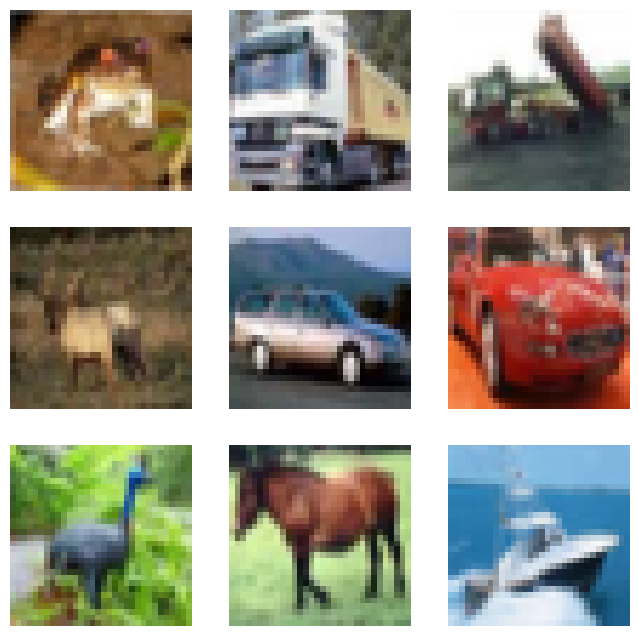

In [9]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
plt.show()

## Task 3: Model 1 – Convolutional Neural Network (CNN)  

### Architecture:
- Convolution layers for feature extraction  
- MaxPooling layers for dimensionality reduction  
- Fully connected layers for classification  

### Configuration:
- Activation Function: ReLU, Softmax  
- Optimizer: Adam  
- Loss Function: Categorical Crossentropy  
- Regularization: Dropout  

CNN is effective in capturing spatial features from images.

In [10]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

### Training CNN Model  
The model is trained using training data with validation split to monitor performance.

In [11]:
cnn_history = cnn_model.fit(X_train, y_train,
                           epochs=10,
                           batch_size=64,
                           validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3268 - loss: 1.8270 - val_accuracy: 0.4751 - val_loss: 1.4925
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4452 - loss: 1.5266 - val_accuracy: 0.5571 - val_loss: 1.2574
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4882 - loss: 1.4072 - val_accuracy: 0.5765 - val_loss: 1.1968
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5203 - loss: 1.3288 - val_accuracy: 0.6023 - val_loss: 1.1384
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5378 - loss: 1.2790 - val_accuracy: 0.6076 - val_loss: 1.1279
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5563 - loss: 1.2254 - val_accuracy: 0.6200 - val_loss: 1.0926
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5668 - loss: 1.1971 - val_accuracy: 0.6398 - val_loss: 1.0217
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5783 - loss: 1.1592 - val_accuracy: 0

### CNN Evaluation Results  
The model performance is evaluated using classification metrics such as accuracy, precision, recall, and F1-score.

In [12]:
cnn_pred = cnn_model.predict(X_test)
cnn_pred_classes = np.argmax(cnn_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, cnn_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.77      0.66      0.71      1000
           1       0.86      0.70      0.77      1000
           2       0.61      0.37      0.46      1000
           3       0.44      0.45      0.44      1000
           4       0.57      0.61      0.59      1000
           5       0.50      0.65      0.56      1000
           6       0.70      0.80      0.75      1000
           7       0.75      0.70      0.72      1000
           8       0.70      0.84      0.76      1000
           9       0.74      0.78      0.76      1000

    accuracy                           0.66     10000
   macro avg       0.66      0.66      0.65     10000
weighted avg       0.66      0.66      0.65     10000



In [13]:
# reshape for LSTM
X_train_lstm = X_train.reshape(-1, 32, 96)
X_test_lstm = X_test.reshape(-1, 32, 96)

## Task 3: Model 2 – LSTM Model  

### Approach:
Images are reshaped into sequences to be processed by LSTM.

### Architecture:
- LSTM layer for sequence learning  
- Dense layers for classification  

### Configuration:
- Activation: ReLU, Softmax  
- Optimizer: Adam  
- Loss: Categorical Crossentropy  

LSTM is generally used for sequential data but is applied here for comparison purposes.

In [14]:
lstm_model = models.Sequential([
    layers.LSTM(64, input_shape=(32,96)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

lstm_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Training LSTM Model  
The reshaped dataset is used to train the LSTM model and evaluate its performance.

In [ ]:
lstm_history = lstm_model.fit(X_train_lstm, y_train,
                             epochs=10,
                             batch_size=64,
                             validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2415 - loss: 2.0364 - val_accuracy: 0.3458 - val_loss: 1.7809
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3414 - loss: 1.7919 - val_accuracy: 0.3939 - val_loss: 1.6717
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3851 - loss: 1.6908 - val_accuracy: 0.4272 - val_loss: 1.5867
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4110 - loss: 1.6274 - val_accuracy: 0.4382 - val_loss: 1.5609
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4282 - loss: 1.5882 - val_accuracy: 0.4475 - val_loss: 1.5245
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4471 - loss: 1.5425 - val_accuracy: 0.4625 - val_loss: 1.4895
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4567 - loss: 1.5086 - val_accuracy: 0.4747 - val_loss: 1.4599
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4692 - loss: 1.4788 - val_accuracy: 0

### LSTM Evaluation Results  
Performance metrics are calculated and compared with CNN results.

In [ ]:
lstm_pred = lstm_model.predict(X_test_lstm)
lstm_pred_classes = np.argmax(lstm_pred, axis=1)

print(classification_report(y_true, lstm_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.56      0.61      0.59      1000
           1       0.62      0.69      0.65      1000
           2       0.33      0.45      0.38      1000
           3       0.37      0.29      0.32      1000
           4       0.51      0.25      0.34      1000
           5       0.42      0.39      0.40      1000
           6       0.50      0.56      0.53      1000
           7       0.58      0.56      0.57      1000
           8       0.64      0.67      0.65      1000
           9       0.53      0.60      0.56      1000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



## Task 4: Performance Evaluation  

### Metrics Used:
- Accuracy  
- Precision  
- Recall  
- F1-score  

### Plots:
- Training vs Validation Accuracy  
- Training vs Validation Loss  

These graphs help in understanding model performance and overfitting.

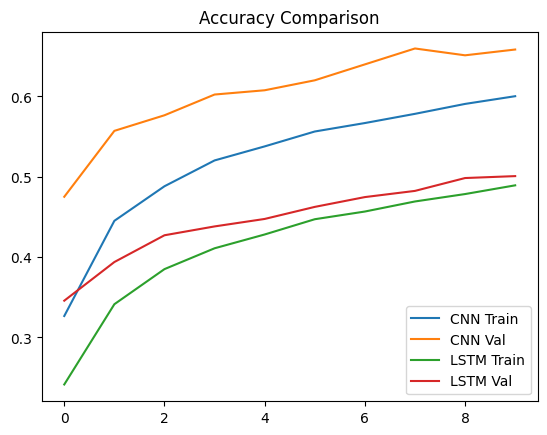

In [ ]:
# Accuracy
plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')

plt.plot(lstm_history.history['accuracy'], label='LSTM Train')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val')

plt.legend()
plt.title("Accuracy Comparison")
plt.show()

### Confusion Matrix  
The confusion matrix shows correct and incorrect predictions for each class.

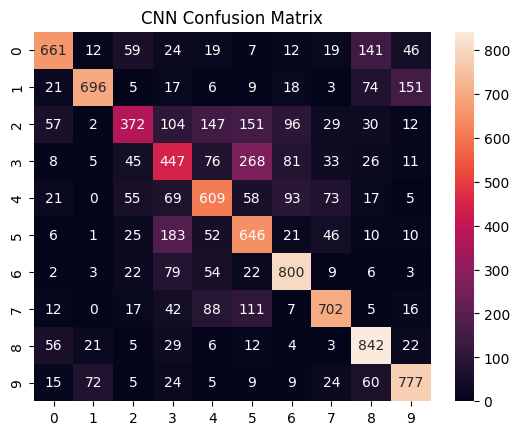

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, cnn_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.show()

## Task 5: Conclusion and Future Work  

### Conclusion:
- CNN achieved higher accuracy compared to LSTM.  
- CNN performs better due to its ability to capture spatial features.  
- LSTM struggled as images are not naturally sequential data.  

### Future Improvements:
- Use advanced models like ResNet or EfficientNet  
- Apply data augmentation  
- Try Transformer-based architectures  

### Submission Links:
- Code: Google Colab Notebook  
- Dataset: CIFAR-10 (Keras Dataset)  
- GitHub: (Add your repository link here)